# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import seaborn as sns
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.ticker import PercentFormatter
from tqdm import tqdm
import glob
import pickle

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.graph_fct as graph_fct
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.utils as utils
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts




# get vocabs

df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
                 .filter(pl.col("date").dt.year()<2026)
                 .filter(pl.col("coding_system") == "SNOMED")
                 .sort(by = "len", descending=True))


# analyze the tokenizer

In [ ]:
def prepare_subgraph (D:int, mapped_ids: list):
    df_relations = pl.read_parquet(f"{config.BasicConfig().relation_path}")

    # remove root concept
    df_relations = df_relations.filter(~pl.col("dst.id").is_in(config.TokenizerParam().exclude_cpt))

    # build graph and combine
    whole_graph = graph_fct.build_relations_graph(df_relations, col_src="src.id", col_dst="dst.id", col_relation="relation")
    combined_subgraphs = graph_fct.get_combined_subgraphs_from_nodes(whole_graph, mapped_ids, D)
    df_cpt = pl.read_parquet(config.BasicConfig().concept_path).select("id", "label")
    id_to_label = dict(zip(df_cpt["id"], df_cpt["label"]))
    
    return id_to_label, combined_subgraphs


## 1. build subgraph

In [ ]:
mapped_ids = df_vocab_freq["code"].unique().to_list()
D = config.TokenizerParam().max_dist_candidate

In [ ]:
id_to_label, combined_subgraphs = prepare_subgraph(D = D, mapped_ids = mapped_ids)
with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "wb") as f:
    pickle.dump(id_to_label, f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "wb") as f:
    pickle.dump(combined_subgraphs, f)

combined_subgraphs.number_of_edges(), combined_subgraphs.number_of_nodes(), nx.number_weakly_connected_components(combined_subgraphs)

## 2. greedy selection

In [ ]:
with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]


lambdas_list = np.round(np.arange(0.6, 1.05, 0.1), 1)


for lam in tqdm(lambdas_list):
    selector = tokenizer.LazyGreedyTokenSelector(combined_subgraphs, mapped_ids_overlap, D = D, lam = lam)
    history = selector.select(k = len(mapped_ids_overlap),n_jobs=-1)   # [(token, marginal_gain, cumulative_score), ...]
    df_history =(
        pl.DataFrame(
        history, schema=["token", "gain", "cumulative_score"], orient="row")
        .with_columns(
        pl.col("token").replace_strict(id_to_label, default=None).alias("label"))
        .with_row_index())
    df_history.write_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{lam}.parquet")

In [ ]:
len(mapped_ids_overlap)

## 3. evaluate metrics

In [ ]:
gd_tree_list = glob.glob(config.HERODataVocabsTest.greedy_candidate_path + '/*.parquet')
all_candidates = utils.to_type_dict(gd_tree_list)
mapped_ids = df_vocab_freq["code"].unique().to_list()
D = config.TokenizerParam().max_dist_candidate
print(len(mapped_ids))


with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

Ks = np.arange(2000, 8000, 500)
len(mapped_ids_overlap)


In [ ]:
import multiprocessing as mp
import os

results = []
candidate_col = "token"
tasks = []
for category, file in all_candidates.items():
    if category != "0.0": 
        df = pl.read_parquet(file)
        for k in Ks:
            candidates = df.head(k)[candidate_col].to_list()
            tasks.append(((category, k), candidates))

# Built once and shared across every task instead of being rebuilt per (category, file_type, k):
# A/node_to_idx is the semantic-coverage transition matrix, adj is the out-adjacency used by
# context-tree building. Neither depends on the candidate set T, only on the fixed graph.
A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=tokenizer._init_coverage_worker,
             initargs=(A, node_to_idx, adj, mapped_ids_overlap, D, id_to_label)) as pool:
    task_results = pool.imap_unordered(tokenizer._worker_coverage_score, tasks, chunksize=4)
    for (category, k), metrics in tqdm(task_results, total=len(tasks)):
        results.append({
            "category": category,
            "k": k,
            **metrics,
        })

results_df = pl.DataFrame(results)
results_df.write_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)

In [ ]:
pl.read_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)

In [ ]:
perf_df_all = (pl.read_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)
               .rename({"uncovered_rate": "unknown_rate",
                        "unk_rate": "uncovered_branche_rate"})
               .drop("exact_rate"))

METRIC_CORE = ['conciseness', 'distance_score', 'unique_rate', 'unknown_rate', 'semantic_coverage']


compression_level_dict = {
    "high": [2000, 3500],      # small k, most compression
    "mid":  [4000, 5500],
    "low":  [6000, 7500],   # large k, least compression
}


higher_is_better = {
    "semantic_coverage": True,
    "distance_score": True,
    "unique_rate": True,
    "conciseness": False,
    "unknown_rate": False,
}


# compression rate for each compression level
for compression_level, (k_min, k_max) in compression_level_dict.items():
    print(f"Compression level: {compression_level}, k_min: {k_min}, k_max: {k_max}")
    print(f"compression rate: {k_min/len(mapped_ids):.2%} - {k_max/len(mapped_ids):.2%}")

df_rank_input = (
    perf_df_all
    .select(["category", "k"] + METRIC_CORE)
    .with_columns(
        pl.when(pl.col("k").is_between(*compression_level_dict["high"])).then(pl.lit("high"))
          .when(pl.col("k").is_between(*compression_level_dict["mid"])).then(pl.lit("mid"))
          .when(pl.col("k").is_between(*compression_level_dict["low"])).then(pl.lit("low"))
          .alias("compression_level"))
    .filter(pl.col("compression_level").is_not_null())
)

ranked = (
    df_rank_input
    # rank the λ runs against each other at the same k (rank 1 = best)
    .with_columns([
        pl.col(m).rank(method="average", descending=higher_is_better[m])
          .over("k").alias(f"{m}_rank")
        for m in METRIC_CORE])
    .with_columns(pl.mean_horizontal([f"{m}_rank" for m in METRIC_CORE]).alias("avg_rank"))
)

rank_table = (
    ranked
    # average over the k values in each level
    .group_by(["compression_level", "category"])
    .agg([pl.col(f"{m}_rank").mean() for m in METRIC_CORE]
         + [pl.col("avg_rank").mean()])
    .sort(["compression_level", "avg_rank"])
)

rank_table.write_csv(config.HERODataVocabsTest.rank_perf)



In [ ]:
rank_table


In [ ]:
hi = perf_df_all.filter(pl.col("category") == "0.9")
hi

# tokenize with lamdas and k

In [ ]:
import polars as pl
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts

def flat_tokens(tree):
    """All tokens in the tree, relation types ignored (a set: each token once)."""
    return {tok for ctx in _iter_contexts(tree) for tok, _ in ctx.tokens}


with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)


In [ ]:
LAMBDA = "0.9"
K = 1000
D = config.TokenizerParam().max_dist_candidate

# 1. once per graph: out-adjacency (non-IS_A edges first, IS_A last)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

# 2. the vocabulary T: top-k tokens of one greedy run
candidates = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet").head(K)["token"].to_list()
T = set(candidates)   # use a set!

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_by_patient["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

# 3. every mapped concept at once -> {concept_id: Context}
trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)

# 4. get fletten tokens
concept_to_tokens = {c: flat_tokens(t) for c, t in trees.items()}

# get performance
from src.graph_tokenizer_gd_tree_dev.eval import evaluate as eval_all_metrics

A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)   # skip if already built

metrics = eval_all_metrics(mapped_ids_overlap, adj, T, D, id_to_label)
S = tokenizer.compute_semantic_coverage(A, node_to_idx, T, D)
metrics["semantic_coverage"] = tokenizer.semantic_coverage_score(S, node_to_idx, mapped_ids_overlap)
metrics


In [ ]:
df_vocab_freq = df_vocab_freq.filter(pl.col("code").is_in(mapped_ids_overlap))

df_tokenized = pl.DataFrame({
    "original": list(concept_to_tokens.keys()),
    "tokenized_list": [list(toks) for toks in concept_to_tokens.values()],
})
df_tokenized_vocab_freq = df_tokenized.join(df_vocab_freq, left_on="original", right_on="code").with_columns(n_tokens = pl.col("tokenized_list").list.len())
# df_tokenized_vocab_by_patient = df_tokenized.join(df_vocab_by_patient, left_on="original", right_on="code")# .explode("tokenized_list")


In [ ]:
import src.graph_tokenizer_gd_tree_dev.longtail_analysis as longtail_analysis

from collections import Counter
from src.graph_tokenizer_gd_tree_dev.tokenizer import signature

total = df_tokenized_vocab_freq["len"].sum()
unk   = set(df_tokenized_vocab_freq.filter(pl.col("n_tokens") == 0)["original"].to_list())
top_k = set(df_tokenized_vocab_freq.sort("len", descending=True).head(K)["original"].to_list())

# Q1: concepts AND usage lost, ours vs truncation
print("ours unknown:", len(unk),
      f"| {df_tokenized_vocab_freq.filter(pl.col('original').is_in(list(unk)))['len'].sum() / total:.2%} of occurrences")
print("truncation unknown:", df_tokenized_vocab_freq.height - K,
      f"| {1 - df_tokenized_vocab_freq.filter(pl.col('original').is_in(list(top_k)))['len'].sum() / total:.2%} of occurrences")
print("our unknowns that truncation would keep:", len(unk & top_k))
print("our unknowns not in the graph:", sum(c not in combined_subgraphs for c in unk))

# Q2: is non-uniqueness mostly the empty representation?
sig_counts = Counter(signature(t) for t in trees.values())
print("distinct signatures among unknown concepts:", len({signature(trees[c]) for c in unk}))
represented = [c for c in trees if c not in unk]
print("unique among represented:",
      sum(sig_counts[signature(trees[c])] == 1 for c in represented), "/", len(represented))
print("distinct representations overall:", len(sig_counts))

# comparison of occurrence percentage troncated vs tokenized

In [3]:
from src.graph_tokenizer_gd_tree_dev.k_sweep import sweep_k, plot_sweep

def flat_tokens(tree):
    """All tokens in the tree, relation types ignored (a set: each token once)."""
    return {tok for ctx in _iter_contexts(tree) for tok, _ in ctx.tokens}


with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

# df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
#                  .filter(pl.col("coding_system") == "SNOMED")
#                  .sort(by = "len", descending=True))

df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
                 .filter(pl.col("date").dt.year()<2026)
                 .filter(pl.col("coding_system") == "SNOMED")
                 .group_by("code").agg(pl.col("len").sum())
                 .sort(by = "len", descending=True))



In [4]:
LAMBDA = "0.9"

D = config.TokenizerParam().max_dist_candidate
adj = tokenizer.build_out_adjacency(combined_subgraphs)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

df_vocab_freq = (df_vocab_freq
                 .filter(pl.col("code").is_in(mapped_ids_overlap))
                 .select("code", "len",pl.cum_sum("len").alias("cum_sum"))
                 .with_columns(pl.col("cum_sum")/pl.col("len").sum().alias("cum_pct")))

Ks_sweep = [250, 500, 1000, 2000, 3500, 5000, 7500, 10000, len(mapped_ids_overlap)]


In [22]:
df_vocab_freq.describe()
len(df_vocab_freq.filter(pl.col("cum_sum") <= 0.99))/len(mapped_ids_overlap)*100


10.177153329260843

In [26]:
f = df_freq.sort("occurrences", descending=True)
cum = f["occurrences"].cum_sum() / f["occurrences"].sum()
print("median occurrences:", f["occurrences"].median())
print("top 10% of codes cover:", round(100 * cum[int(0.1 * f.height) - 1], 1), "% of events")

median occurrences: 28.0
top 10% of codes cover: 99.0 % of events


In [43]:
df_freq.filter(pl.col("occurrences") < 100)["occurrences"].sum()/df_freq["occurrences"].sum()*100

0.07039231654578636

## claude 1

In [21]:
import src.graph_tokenizer_gd_tree_dev.ehr_tokenization as et

df_freq = et.code_frequencies(df_vocab_freq, freq_col="len")          # one row per code
codes = [c for c in mapped_ids_overlap if c in set(df_freq["code"])]
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
Ks = [250, 500, 1000, 2000, 3500, 5000, 7500, 10000, len(codes)]

per_code = et.tokenize_all_k(codes, ranked, Ks, adj, D, df_freq, id_to_label)
per_code.write_parquet(f"{config.HERODataVocabsTest.path}per_code_tokenized.parquet")

cov  = et.coverage(per_code)      # 1. code and event coverage
cst  = et.cost(per_code)          # 3. tokens per event, total tokens in the corpus
uniq = et.uniqueness(per_code)    # 2. unique representations (tree / flat / truncation)
toks = et.token_stats(per_code)   #    token frequency, sharing, unused tokens
lt   = et.longtail(per_code)      # 4. rare-code expressivity, per k and frequency bin

lt.write_excel(f"{config.HERODataVocabsTest.path}analysis/lt.xlsx")
cov.write_excel(f"{config.HERODataVocabsTest.path}analysis/cov.xlsx")
uniq.write_excel(f"{config.HERODataVocabsTest.path}analysis/uniq.xlsx")
toks.write_excel(f"{config.HERODataVocabsTest.path}analysis/toks.xlsx")
cst.write_excel(f"{config.HERODataVocabsTest.path}analysis/cst.xlsx")



100%|██████████| 9/9 [00:16<00:00,  1.84s/it]


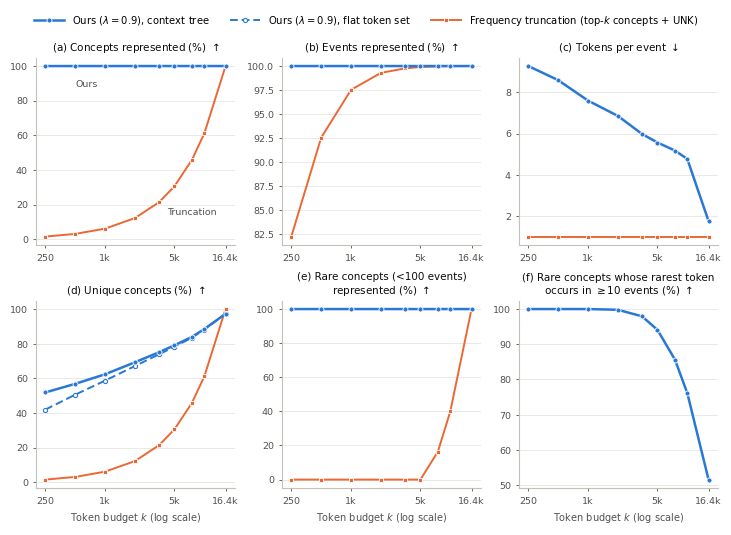

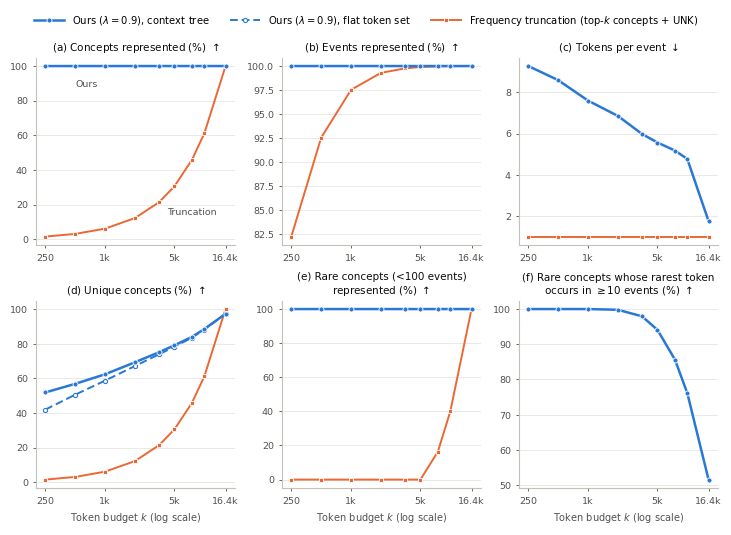

In [44]:
from src.graph_tokenizer_gd_tree_dev.ehr_plots import plot_ehr_summary

import importlib; importlib.reload(et)

per_code = per_code.with_columns(pl.col("occurrences").cast(pl.Int64))   # fix the table you already have

plot_ehr_summary(et.coverage(per_code), et.cost(per_code), et.uniqueness(per_code),
                 et.longtail(per_code), fname="figures/ehr_summary.pdf")

## claude longtail distribution analysis

In [28]:
dist = et.distribution_stats(per_code)                  # 4 vocabularies x 9 budgets
dist.filter(pl.col("k") == 5000)

rf = et.rank_frequency(per_code, K=5000)                # data for the log-log rank-frequency plot
rf

vocabulary,rank,occurrences
str,i32,f64
"""raw_codes""",1,4.952019e6
"""raw_codes""",2,4.769991e6
"""raw_codes""",3,4.20461e6
"""raw_codes""",4,4.183965e6
"""raw_codes""",5,4.153599e6
…,…,…
"""ours""",4987,1.0
"""ours""",4988,1.0
"""ours""",4989,1.0


8.0% of represented concepts gain nothing


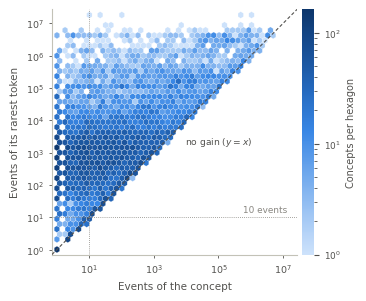

In [53]:
import importlib
import src.graph_tokenizer_gd_tree_dev.ehr_plots as ep
importlib.reload(ep)

fig, on_diag = ep.plot_borrowed_strength(per_code, k=5000, rare=10,
                                        fname="figures/borrowed_strength.pdf")
print(f"{on_diag:.1%} of represented concepts gain nothing")

In [30]:
dist.write_csv("dist.csv")

## my codes

In [ ]:
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
code_freq = dict(zip(df_vocab_freq["code"], df_vocab_freq["len"]))

Ks = [250, 500, 1000, 2000, 3500, 5000, 7500, 10000, len(mapped_ids_overlap)]
frames = []
for K in tqdm(Ks):
    T = set(ranked[:K])
    trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)
    frames.append(
        pl.DataFrame({
            "original": list(trees.keys()),
            "tokenized_list": [sorted({t for ctx in _iter_contexts(tr) for t, _ in ctx.tokens})
                               for tr in trees.values()],
            "context_tree": [tree for tree in trees.values()]
        }).with_columns(pl.lit(K).alias("k"))
    )
df_tokenized_k = pl.concat(frames)


# res = sweep_k(Ks, ranked, mapped_ids_overlap, code_freq, adj, D, id_to_label,
#               fractions=(1.0,), min_occ=(100,))
df_tokenized_k = df_tokenized_k.join(df_vocab_freq, left_on="original", right_on="code").with_columns(pl.col("len").alias("occurrences")).sort("occurrences", descending=True)

In [ ]:
from src.graph_tokenizer_gd_tree_dev.tokenizer import signature
trees
signature(df_tokenized_k["context_tree"][0])

In [ ]:
res.write_csv("res.csv")
# plot_sweep(res, fname="k_sweep_real_data.pdf")
plot_sweep(res)



In [ ]:
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts
from src.graph_tokenizer_gd_tree_dev.longtail_analysis import (
    prepare, borrowed_strength, rare_token_diagnosis, plot_borrowed_strength)

K, RARE, LAMBDA = 5000, 10, "0.9"

df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
                 .filter(pl.col("date").dt.year()<2026)
                 .filter(pl.col("coding_system") == "SNOMED")
                 .group_by("code").agg(pl.col("len").sum())
                 .sort(by = "len", descending=True))

assert df_vocab_freq["code"].n_unique() == df_vocab_freq.height   # one row per code

# vocabulary and context trees at the SAME k as the truncation comparison
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
T = set(ranked[:K])
trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)

# one row per code: its flat token set (empty list = no token at all)
df_tokenized = pl.DataFrame({
    "original": list(trees.keys()),
    "tokenized_list": [sorted({t for ctx in _iter_contexts(tr) for t, _ in ctx.tokens})
                       for tr in trees.values()],
})

codes, pairs, tok = prepare(df_tokenized, df_vocab_freq, freq_col="len")
table, per_code = borrowed_strength(codes, pairs, tok, k=K, rare=RARE)
print(table)
print(rare_token_diagnosis(codes, tok, rare=RARE))
plot_borrowed_strength(per_code, rare=RARE, fname=f"figures/borrowed_strength_k{K}.png")

# find concepts with the same set of tokens but diff context tree

In [ ]:
from collections import Counter, defaultdict
import re
import polars as pl
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts
from src.graph_tokenizer_gd_tree_dev.tokenizer import signature

# skip these 4 lines if `trees` is already built
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
k = 5000
T = set(ranked[:k])
trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)

EXCLUDE = ("?",)   # words to exclude from example labels; add more, e.g. ("substance", "product")

label = lambda x: id_to_label.get(x, x)
keep = lambda c: not any(w in label(c).lower() for w in EXCLUDE)
tag = lambda c: (m.group(1) if (m := re.search(r"\(([^()]*)\)\s*$", label(c))) else "?")

def flat_tokens(tree): return frozenset(t for ctx in _iter_contexts(tree) for t, _ in ctx.tokens)
def has_uncovered(tree): return any(ctx.uncovered for ctx in _iter_contexts(tree))
def n_contexts(tree): return sum(1 for _ in _iter_contexts(tree))
def sexpr(ctx):
    items = [label(t) for t, _ in ctx.tokens]
    if ctx.uncovered: items.append("∅")
    items += [f"{label(sub.relation)}({sexpr(sub)})" for sub in ctx.subcontexts]
    return ", ".join(items)

# counts over ALL concepts, so "unique" means unique in the whole vocabulary
flat = {c: flat_tokens(trees[c]) for c in mapped_ids_overlap}
sig = {c: signature(trees[c]) for c in mapped_ids_overlap}
flat_n = Counter(flat.values()); sig_n = Counter(sig.values())

gain = [c for c in mapped_ids_overlap if flat[c] and flat_n[flat[c]] > 1 and sig_n[sig[c]] == 1]
print(f"{len(gain)} concepts gain uniqueness from the tree; {sum(map(keep, gain))} pass the label filter")
print("by semantic tag:", Counter(tag(c) for c in gain).most_common())

# examples: built only from concepts that pass the filter
groups = defaultdict(lambda: defaultdict(list))
for c in mapped_ids_overlap:
    if flat[c] and keep(c):
        groups[flat[c]][sig[c]].append(c)

examples = [
    (fs, by_sig) for fs, by_sig in groups.items()
    if len(by_sig) >= 2 and any(sig_n[s] == 1 for s in by_sig)   # at least one tree is truly unique
]
examples.sort(key=lambda e: (
    any(has_uncovered(trees[cs[0]]) for cs in e[1].values()),   # fully covered first
    len(e[0]),                                                   # small token sets first
    max(n_contexts(trees[cs[0]]) for cs in e[1].values()),       # small trees first
))

print(f"\n{len(examples)} flat token sets with 2+ trees (after filter)")
for fs, by_sig in examples:
    print(f"\nflat token set: {sorted(label(t) for t in fs)}")
    for s, cs in by_sig.items():
        print(f"  {label(cs[0])}  ({sig_n[s]} concept(s) with this tree)")
        print(f"     ({sexpr(trees[cs[0]])})")

In [ ]:
cands = ["Alcohol induced disorder co-occurrent and due to alcohol dependence (disorder)",
         "Alcohol dependence (disorder)",
         "Shock due to anaphylaxis (disorder)", "Anaphylaxis (disorder)",
         "Cardiomyopathy associated with another disorder (disorder)", "Familial cardiomyopathy (disorder)"]
lab2id = {label(c): str(c) for c in mapped_ids_overlap}
for name in cands:
    cid = lab2id.get(name, "NOT FOUND")
    kind = "EXTENSION" if cid[-3:-1] == "10" else "international ID"   # SCTID partition digits
    print(f"{cid:>20}  {kind:<16}  {name}")